# Ablation Analysis — XGBoost

Ablation analysis is a model diagnostics technique borrowed from neuroscience: just as
researchers lesion brain regions to identify their function, we systematically remove
features or feature groups to quantify their marginal contribution to predictions.

**Why ablation over standard feature importance?** Tree-based gain importance tells us
how often and how effectively a feature is used in splits, but it cannot distinguish
between *indispensable* features and *convenient but replaceable* ones. A feature may
have high gain importance simply because the model chose it over a correlated alternative.
Ablation directly measures whether removing a feature actually degrades out-of-sample
performance — the ground truth of feature utility.

**Methodology:**
- Remove one feature (or feature group) at a time, re-run 5-fold time-series CV with the same tuned hyperparameters and threshold
- Measure the drop in PR-AUC and F1 relative to the full model
- A large drop indicates the feature provides *unique* predictive signal; a small drop suggests it is *redundant* with other features

**Inputs:**
- `data/xgboost_model_config.pkl` — tuned hyperparameters, decision threshold, and selected features from the XGBoost model notebook
- `data/milestone_ii_preprocessed.pkl` — fully engineered feature set

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_recall_curve, auc, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load model configuration
with open('../data/xgboost_model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

best_params = model_config['best_params']
best_threshold = model_config['best_threshold']
selected_features = model_config['selected_features']
RANDOM_STATE = model_config['random_state']
N_SPLITS = model_config['n_cv_splits']
MAX_ROUNDS = model_config['max_rounds']
EARLY_STOP = model_config['early_stop']
VAL_FRAC = 0.2

# Load data
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < model_config['data_cutoff']]
X = df_flat[selected_features].copy().replace([np.inf, -np.inf], np.nan)
y = df_flat['pre_recession']

print(f'Features: {len(selected_features)}, Observations: {len(X)}')
print(f'Threshold: {best_threshold:.2f}')

Features: 37, Observations: 5292
Threshold: 0.50


## Feature Group Definitions

Rather than testing all 37 features individually (which would be expensive and hard to
interpret), we first organize features into **economically meaningful groups**. This
captures the joint contribution of related indicators — for example, removing all yield
curve features at once reveals whether *any* interest rate signal matters, not just
whether one specific maturity is important.

Groups are constructed dynamically from the selected feature names so that the analysis
automatically adapts if the feature selection pipeline changes upstream.

In [2]:
# Build feature groups dynamically from selected features
FEATURE_GROUPS = {}

yield_feats = [f for f in selected_features
               if any(x in f for x in ['yield_spread', 'yield_curve_inverted',
                                        '10_yr_yld', '3_mo_yld'])]
if yield_feats:
    FEATURE_GROUPS['Yield Curve & Rates'] = yield_feats

financial_feats = [f for f in selected_features
                   if any(x in f for x in ['vix', 'oil', 'copper', 'gps',
                                            'national_share_price'])]
if financial_feats:
    FEATURE_GROUPS['Financial Markets'] = financial_feats

labor_feats = [f for f in selected_features if 'unemployment' in f]
if labor_feats:
    FEATURE_GROUPS['Labor Market'] = labor_feats

sentiment_feats = [f for f in selected_features
                   if any(x in f for x in ['consumer_conf', 'comp_consumer_conf'])]
if sentiment_feats:
    FEATURE_GROUPS['Consumer Confidence'] = sentiment_feats

epu_feats = [f for f in selected_features if 'epu' in f]
if epu_feats:
    FEATURE_GROUPS['Policy Uncertainty (EPU)'] = epu_feats

cli_feats = [f for f in selected_features if 'cli' in f]
if cli_feats:
    FEATURE_GROUPS['Composite Leading Indicator'] = cli_feats

real_econ_feats = [f for f in selected_features
                   if any(x in f for x in ['real_gdp', 'ind_out', 'retail', 'cpi',
                                            'pcar_reg'])]
if real_econ_feats:
    FEATURE_GROUPS['Real Economy'] = real_econ_feats

country_feats = [f for f in selected_features if f.startswith('country_')]
if country_feats:
    FEATURE_GROUPS['Country Dummies'] = country_feats

lag_feats = [f for f in selected_features if '_lag_' in f]
if lag_feats:
    FEATURE_GROUPS['All Lagged Features'] = lag_feats

# Show groups
for name, feats in FEATURE_GROUPS.items():
    print(f'\n{name} ({len(feats)} features):')
    for f in sorted(feats):
        print(f'  {f}')

# Check for uncategorized features
all_grouped = set()
for feats in FEATURE_GROUPS.values():
    all_grouped.update(feats)
uncategorized = set(selected_features) - all_grouped
if uncategorized:
    print(f'\nUncategorized: {sorted(uncategorized)}')
    FEATURE_GROUPS['Other'] = sorted(uncategorized)


Yield Curve & Rates (6 features):
  10_yr_yld
  10_yr_yld_diff_12mo
  10_yr_yld_diff_6mo
  3_mo_yld_diff_6mo
  3_mo_yld_lag_12mo
  yield_curve_inverted_lag_3mo

Financial Markets (12 features):
  copper_lag_6mo
  copper_log_12mo
  copper_log_3mo
  gps
  gps_log_1mo
  national_share_price_rolling_std_6mo
  oil_log_12mo
  oil_log_3mo
  vix_log_12mo
  vix_log_3mo
  vix_log_6mo
  vix_rolling_mean_3mo_lag_12mo

Labor Market (4 features):
  unemployment_12mo_min
  unemployment_rate_diff_1mo
  unemployment_rate_diff_3mo
  unemployment_rate_diff_6mo

Consumer Confidence (2 features):
  comp_consumer_conf_diff_12mo
  comp_consumer_conf_lag_6mo

Policy Uncertainty (EPU) (1 features):
  epu_rolling_std_12mo

Composite Leading Indicator (3 features):
  cli
  cli_dev
  cli_lag_12mo

Real Economy (6 features):
  cpi_log_12mo
  ind_out_log_3mo
  ind_out_log_6mo
  pcar_reg
  real_gdp_log_6mo
  retail_vol_diff_12mo

Country Dummies (3 features):
  country_Canada
  country_South Korea
  country_USA

Al

**Observations on group composition:**
- **Financial Markets** is the largest group (12 features) spanning VIX volatility, commodity prices (oil, copper, gold), and equity indices — all fast-moving, market-based signals.
- **Composite Leading Indicator** contains only 3 features (`cli`, `cli_dev`, `cli_lag_12mo`) but, as we will see, is by far the most important group. The OECD CLI is itself a composite of multiple leading indicators, so it compresses substantial economic information into a single series.
- **All Lagged Features** overlaps with other groups by design — it collects the time-lagged variants of features that also appear in their contemporaneous form elsewhere. This makes its ablation result particularly informative: if removing lags does not hurt, the model is not relying on historical memory beyond what current values provide.
- Note that some features appear in multiple groups (e.g., `cli_lag_12mo` appears in both "Composite Leading Indicator" and "All Lagged Features"). Each group ablation removes all features matching that group, regardless of overlap.

In [3]:
def run_ablation_cv(feature_subset, y):
    """Run 5-fold time-series CV with tuned HP on a feature subset."""
    X_sub = df_flat[feature_subset].copy().replace([np.inf, -np.inf], np.nan)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sub)):
        X_train_full = X_sub.iloc[train_idx]
        y_train_full = y.iloc[train_idx]
        X_test = X_sub.iloc[test_idx]
        y_test = y.iloc[test_idx]

        val_size = int(len(X_train_full) * VAL_FRAC)
        X_train = X_train_full.iloc[:-val_size]
        y_train = y_train_full.iloc[:-val_size]
        X_val = X_train_full.iloc[-val_size:]
        y_val = y_train_full.iloc[-val_size:]

        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            **best_params, n_estimators=MAX_ROUNDS,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0, eval_metric='aucpr',
            early_stopping_rounds=EARLY_STOP,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_proba = model.predict_proba(X_test)[:, 1]
        prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
        pr_auc_val = auc(rec_arr, prec_arr)
        roc_val = roc_auc_score(y_test, y_proba)
        y_pred = (y_proba >= best_threshold).astype(int)
        f1_val = f1_score(y_test, y_pred, zero_division=0)
        fold_metrics.append({'pr_auc': pr_auc_val, 'roc_auc': roc_val, 'f1': f1_val})

    mdf = pd.DataFrame(fold_metrics)
    return {
        'pr_auc_mean': mdf['pr_auc'].mean(), 'pr_auc_std': mdf['pr_auc'].std(),
        'roc_auc_mean': mdf['roc_auc'].mean(),
        'f1_mean': mdf['f1'].mean(), 'f1_std': mdf['f1'].std(),
    }

print('Ablation CV helper defined.')

Ablation CV helper defined.


**Implementation note:** Each ablation experiment re-trains the full 5-fold time-series
CV from scratch using the *same* tuned hyperparameters and threshold as the original model.
This isolates the effect of feature removal from any hyperparameter confounding. However,
it is worth noting that the hyperparameters were originally tuned with all features present,
so a feature group that appears redundant here might become more valuable under a different
hyperparameter configuration optimized for the reduced feature set.

## Full Model Baseline

Establish baseline performance with all selected features before running ablation.

In [4]:
baseline = run_ablation_cv(selected_features, y)
print(f'Full model ({len(selected_features)} features):')
print(f'  PR-AUC: {baseline["pr_auc_mean"]:.4f} +/- {baseline["pr_auc_std"]:.4f}')
print(f'  ROC-AUC: {baseline["roc_auc_mean"]:.4f}')
print(f'  F1: {baseline["f1_mean"]:.4f} +/- {baseline["f1_std"]:.4f}')

Full model (37 features):
  PR-AUC: 0.4783 +/- 0.1079
  ROC-AUC: 0.7310
  F1: 0.4278 +/- 0.0730


The full model achieves a PR-AUC of **0.478** and F1 of **0.428** — these serve as our
reference point. The relatively high standard deviation on PR-AUC (+/- 0.108) reflects
the inherent variability of time-series CV with expanding windows: earlier folds have less
training data and may span different economic regimes than later folds. All ablation
deltas below should be interpreted against this backdrop of natural fold-to-fold variance.

## Feature Group Ablation

Remove each feature group entirely and measure the performance drop. A large drop
indicates the group provides unique predictive information that other features
cannot compensate for.

In [5]:
group_results = []
for group_name, group_feats in FEATURE_GROUPS.items():
    remaining = [f for f in selected_features if f not in group_feats]
    if not remaining:
        continue
    print(f'Removing {group_name} ({len(group_feats)} features, {len(remaining)} remaining)...')
    result = run_ablation_cv(remaining, y)
    result['group'] = group_name
    result['n_removed'] = len(group_feats)
    result['n_remaining'] = len(remaining)
    result['pr_auc_drop'] = baseline['pr_auc_mean'] - result['pr_auc_mean']
    result['f1_drop'] = baseline['f1_mean'] - result['f1_mean']
    group_results.append(result)

group_df = pd.DataFrame(group_results).sort_values('pr_auc_drop', ascending=False)

print('\nGroup Ablation Results (sorted by PR-AUC drop):')
print('=' * 95)
for _, row in group_df.iterrows():
    print(f'  {row["group"]:35s} | Removed: {row["n_removed"]:2d} | '
          f'PR-AUC: {row["pr_auc_mean"]:.4f} (delta={row["pr_auc_drop"]:+.4f}) | '
          f'F1: {row["f1_mean"]:.4f} (delta={row["f1_drop"]:+.4f})')

Removing Yield Curve & Rates (6 features, 31 remaining)...
Removing Financial Markets (12 features, 25 remaining)...
Removing Labor Market (4 features, 33 remaining)...
Removing Consumer Confidence (2 features, 35 remaining)...
Removing Policy Uncertainty (EPU) (1 features, 36 remaining)...
Removing Composite Leading Indicator (3 features, 34 remaining)...
Removing Real Economy (6 features, 31 remaining)...
Removing Country Dummies (3 features, 34 remaining)...
Removing All Lagged Features (6 features, 31 remaining)...

Group Ablation Results (sorted by PR-AUC drop):
  Composite Leading Indicator         | Removed:  3 | PR-AUC: 0.3388 (delta=+0.1395) | F1: 0.3507 (delta=+0.0772)
  Real Economy                        | Removed:  6 | PR-AUC: 0.4521 (delta=+0.0262) | F1: 0.4301 (delta=-0.0023)
  Consumer Confidence                 | Removed:  2 | PR-AUC: 0.4533 (delta=+0.0250) | F1: 0.4476 (delta=-0.0198)
  Yield Curve & Rates                 | Removed:  6 | PR-AUC: 0.4671 (delta=+0.0111)

**Reading the results:** A positive delta means performance *dropped* when the group was
removed (i.e., the group was helpful). A negative delta means performance *improved*
without it (i.e., the group was adding noise or overfitting).

The Composite Leading Indicator stands out dramatically — removing just 3 features causes
a PR-AUC collapse from 0.478 to 0.339, a **29% relative decrease**. No other group comes
close. This makes economic sense: the OECD CLI is specifically designed to lead business
cycle turning points and aggregates signals from production, orders, stock prices, and
building permits into a single index.

An interesting finding is that **Financial Markets** (the largest group at 12 features)
has one of the smallest impacts when removed. This suggests substantial redundancy among
VIX, oil, copper, gold, and equity features — they likely capture overlapping
risk-sentiment information, so the model can reconstruct the signal from whichever subset
remains.

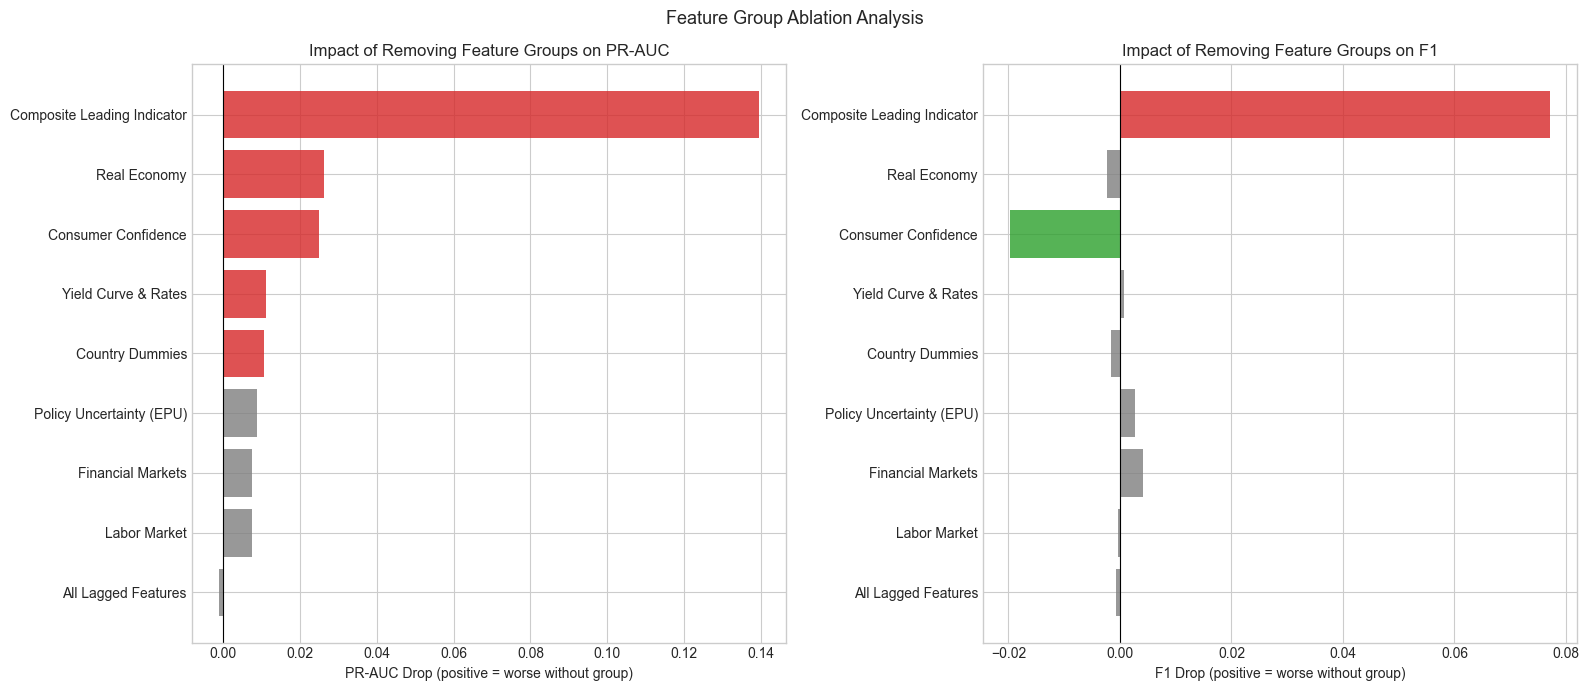

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_df = group_df.sort_values('pr_auc_drop', ascending=True)

colors = ['#d62728' if d > 0.01 else '#2ca02c' if d < -0.01 else '#7f7f7f'
          for d in plot_df['pr_auc_drop']]
axes[0].barh(plot_df['group'], plot_df['pr_auc_drop'], color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('PR-AUC Drop (positive = worse without group)')
axes[0].set_title('Impact of Removing Feature Groups on PR-AUC')

colors_f1 = ['#d62728' if d > 0.01 else '#2ca02c' if d < -0.01 else '#7f7f7f'
             for d in plot_df['f1_drop']]
axes[1].barh(plot_df['group'], plot_df['f1_drop'], color=colors_f1, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('F1 Drop (positive = worse without group)')
axes[1].set_title('Impact of Removing Feature Groups on F1')

plt.suptitle('Feature Group Ablation Analysis', fontsize=13)
plt.tight_layout()
plt.show()

**Interpreting the charts:** Red bars indicate groups whose removal materially hurts
performance (delta > 0.01); green bars indicate groups whose removal slightly *improves*
performance; grey bars are negligible.

Note the divergence between PR-AUC and F1 impacts for some groups. For example, removing
**Consumer Confidence** hurts PR-AUC (+0.025) but actually *improves* F1 (-0.020). This
occurs because PR-AUC measures ranking quality across all thresholds, while F1 is evaluated
at a single fixed threshold (0.50). Consumer confidence features may help the model better
separate pre-recession probabilities in the 0.2–0.4 range (improving PR-AUC) without
changing many predictions that cross the 0.50 decision boundary (leaving F1 flat or slightly
better due to reduced noise).

## Individual Feature Leave-One-Out

While group ablation reveals which *domains* matter, it cannot distinguish the contributions
of individual features within a group. Leave-one-out (LOO) analysis addresses this by
removing one feature at a time from the full model.

We focus on the **top 10 features by gain importance** to keep the analysis tractable.
For each, we measure the performance change when that single feature is excluded. This
reveals which high-importance features are truly irreplaceable vs. which ones simply
happened to be the model's preferred choice among correlated alternatives.

In [7]:
# Compute gain importance to identify top features
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fold_importances = np.zeros((N_SPLITS, len(selected_features)))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_full = X.iloc[train_idx]
    y_train_full = y.iloc[train_idx]
    val_size = int(len(X_train_full) * VAL_FRAC)
    X_tr = X_train_full.iloc[:-val_size]
    y_tr = y_train_full.iloc[:-val_size]
    X_vl = X_train_full.iloc[-val_size:]
    y_vl = y_train_full.iloc[-val_size:]
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    mdl = xgb.XGBClassifier(
        **best_params, n_estimators=MAX_ROUNDS,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0, eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOP,
    )
    mdl.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
    fold_importances[fold] = mdl.feature_importances_

mean_imp = fold_importances.mean(axis=0)
top_indices = np.argsort(mean_imp)[::-1][:10]
top_features = [selected_features[i] for i in top_indices]

print('Top 10 features by gain importance:')
for i, feat in enumerate(top_features, 1):
    print(f'  {i:2d}. {feat} ({mean_imp[selected_features.index(feat)]:.4f})')

# Leave-one-out
loo_results = []
for feat in top_features:
    remaining = [f for f in selected_features if f != feat]
    print(f'Removing {feat}...')
    result = run_ablation_cv(remaining, y)
    result['feature'] = feat
    result['importance'] = mean_imp[selected_features.index(feat)]
    result['pr_auc_drop'] = baseline['pr_auc_mean'] - result['pr_auc_mean']
    result['f1_drop'] = baseline['f1_mean'] - result['f1_mean']
    loo_results.append(result)

loo_df = pd.DataFrame(loo_results).sort_values('pr_auc_drop', ascending=False)

print('\nLeave-One-Out Results (top 10 features):')
print('=' * 95)
for _, row in loo_df.iterrows():
    print(f'  {row["feature"]:45s} | Gain: {row["importance"]:.4f} | '
          f'PR-AUC delta: {row["pr_auc_drop"]:+.4f} | F1 delta: {row["f1_drop"]:+.4f}')

Top 10 features by gain importance:
   1. cli (0.2406)
   2. cli_dev (0.2344)
   3. cpi_log_12mo (0.1025)
   4. ind_out_log_6mo (0.0650)
   5. real_gdp_log_6mo (0.0527)
   6. 10_yr_yld_diff_6mo (0.0476)
   7. cli_lag_12mo (0.0437)
   8. comp_consumer_conf_diff_12mo (0.0377)
   9. 10_yr_yld_diff_12mo (0.0369)
  10. comp_consumer_conf_lag_6mo (0.0270)
Removing cli...
Removing cli_dev...
Removing cpi_log_12mo...
Removing ind_out_log_6mo...
Removing real_gdp_log_6mo...
Removing 10_yr_yld_diff_6mo...
Removing cli_lag_12mo...
Removing comp_consumer_conf_diff_12mo...
Removing 10_yr_yld_diff_12mo...
Removing comp_consumer_conf_lag_6mo...

Leave-One-Out Results (top 10 features):
  cli_dev                                       | Gain: 0.2344 | PR-AUC delta: +0.0384 | F1 delta: -0.0116
  cli                                           | Gain: 0.2406 | PR-AUC delta: +0.0380 | F1 delta: -0.0018
  cpi_log_12mo                                  | Gain: 0.1025 | PR-AUC delta: +0.0196 | F1 delta: -0.0107

**Key observations from LOO results:**

| Tier | Features | PR-AUC Delta | Interpretation |
|------|----------|-------------|----------------|
| **Irreplaceable** | `cli`, `cli_dev` | +0.038 each | These two CLI features are the backbone of the model. Even individually, removing either one causes nearly the same damage as the top LOO feature — and together (as shown in the group ablation) they cause a catastrophic 0.14 drop. |
| **Important** | `cpi_log_12mo`, `10_yr_yld_diff_6mo` | +0.017–0.020 | Inflation dynamics and yield curve movements provide meaningful signal that other features cannot fully replicate. |
| **Moderate** | `10_yr_yld_diff_12mo`, `comp_consumer_conf_diff_12mo`, `cli_lag_12mo`, `comp_consumer_conf_lag_6mo` | +0.007–0.009 | These contribute incrementally but are partially compensated by related features. |
| **Replaceable** | `ind_out_log_6mo`, `real_gdp_log_6mo` | -0.001–0.004 | Despite high gain importance (ranks 4–5), removing them barely changes performance. Other real economy features or the CLI (which incorporates industrial production) fill the gap. |

The most striking finding is the gap between **gain importance** and **ablation impact** for
`real_gdp_log_6mo`: it ranks 5th in gain importance (0.053) but has essentially zero
ablation impact (-0.001). This is a textbook example of why ablation analysis complements
importance scores — the model *uses* GDP growth heavily, but can *reconstruct* its signal
from correlated features like industrial output and CLI when forced to.

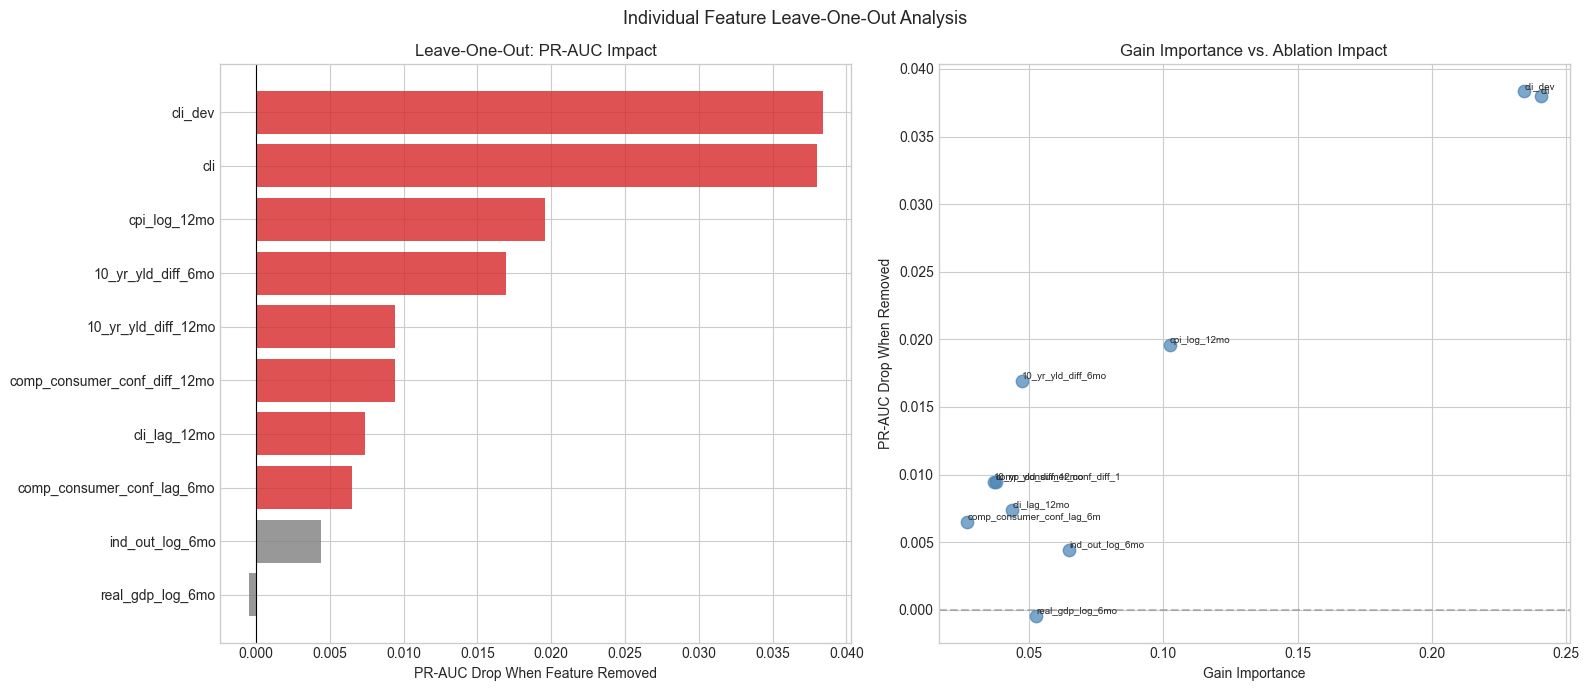

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart of PR-AUC drop
plot_loo = loo_df.sort_values('pr_auc_drop', ascending=True)
colors = ['#d62728' if d > 0.005 else '#2ca02c' if d < -0.005 else '#7f7f7f'
          for d in plot_loo['pr_auc_drop']]
axes[0].barh(plot_loo['feature'], plot_loo['pr_auc_drop'], color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('PR-AUC Drop When Feature Removed')
axes[0].set_title('Leave-One-Out: PR-AUC Impact')

# Scatter: gain importance vs ablation impact
axes[1].scatter(loo_df['importance'], loo_df['pr_auc_drop'],
                s=80, alpha=0.7, color='steelblue')
for _, row in loo_df.iterrows():
    short_name = row['feature'][:25]
    axes[1].annotate(short_name, (row['importance'], row['pr_auc_drop']),
                     fontsize=7, ha='left', va='bottom')
axes[1].set_xlabel('Gain Importance')
axes[1].set_ylabel('PR-AUC Drop When Removed')
axes[1].set_title('Gain Importance vs. Ablation Impact')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Individual Feature Leave-One-Out Analysis', fontsize=13)
plt.tight_layout()
plt.show()

**Left panel:** The horizontal bar chart confirms the tier structure — `cli` and `cli_dev`
form a clear top tier, followed by `cpi_log_12mo` and `10_yr_yld_diff_6mo`, with the
remaining features clustered near zero.

**Right panel (scatter):** If gain importance perfectly predicted ablation impact, all
points would lie along a diagonal line. Instead, we see meaningful scatter:
- `cli` and `cli_dev` cluster in the **upper-right** (high gain, high ablation impact) — these are genuinely critical features.
- `real_gdp_log_6mo` and `ind_out_log_6mo` sit in the **lower-right** (high gain, low ablation impact) — the model prefers them but doesn't need them.
- No features appear in the **upper-left** (low gain, high ablation impact), which would indicate hidden dependencies.

This pattern suggests the model's feature usage is broadly sensible: the features it relies
on most heavily are also the ones it cannot easily replace.

## Lagged Feature Ablation

The preprocessing pipeline creates 1, 3, 6, and 12-month lagged versions of key indicators
to capture temporal dynamics — the idea being that *changes over time* (e.g., a deteriorating
CLI over the past 12 months) may be more predictive than the current level alone.

This section tests whether those lagged features provide genuine early-warning capability
or whether contemporaneous features already encode sufficient information for XGBoost to
learn temporal patterns implicitly (e.g., through tree depth and interaction effects).

In [9]:
lag_feats_in_model = [f for f in selected_features if '_lag_' in f]
non_lag_feats = [f for f in selected_features if '_lag_' not in f]

if lag_feats_in_model:
    result_no_lags = run_ablation_cv(non_lag_feats, y)

    print(f'Lagged features: {len(lag_feats_in_model)}')
    print(f'Non-lagged features: {len(non_lag_feats)}')
    print(f'\nFull model:    PR-AUC = {baseline["pr_auc_mean"]:.4f}, F1 = {baseline["f1_mean"]:.4f}')
    print(f'Without lags:  PR-AUC = {result_no_lags["pr_auc_mean"]:.4f} '
          f'(delta = {baseline["pr_auc_mean"] - result_no_lags["pr_auc_mean"]:+.4f}), '
          f'F1 = {result_no_lags["f1_mean"]:.4f} '
          f'(delta = {baseline["f1_mean"] - result_no_lags["f1_mean"]:+.4f})')
else:
    print('No lagged features in selected feature set.')

Lagged features: 6
Non-lagged features: 31

Full model:    PR-AUC = 0.4783, F1 = 0.4278
Without lags:  PR-AUC = 0.4793 (delta = -0.0011), F1 = 0.4286 (delta = -0.0008)


Removing all six lagged features produces virtually no change in PR-AUC (delta = -0.001) or
F1 (delta = -0.001). In fact, performance *marginally improves* without them, though the
difference is well within noise.

**Why are lags redundant for XGBoost?** Unlike sequence models (e.g., LSTM) that explicitly
model temporal dependencies, XGBoost treats each observation independently. The lagged
features were designed to inject historical context, but in practice:
1. The contemporaneous values of CLI, consumer confidence, VIX, copper, and yield curve
   inversion already capture the *current state* of the economy, which is itself shaped by
   recent history.
2. The diff-based features (e.g., `unemployment_rate_diff_6mo`, `10_yr_yld_diff_12mo`)
   already encode rate-of-change information that lags were meant to provide.
3. XGBoost's expanding-window CV means later folds train on progressively more data,
   reducing the need for explicit lag features to capture regime transitions.

**Implication:** The 6 lagged features could be removed from the XGBoost model without
performance loss, simplifying the model and reducing the risk of overfitting. However,
they may still be valuable for other model architectures (e.g., LSTM) that handle
sequential information differently.

## Yield Curve Ablation

The yield curve (specifically the 10-year minus 3-month Treasury spread) is arguably the
most studied recession predictor in macroeconomics. An inverted yield curve — where
short-term rates exceed long-term rates — has preceded every U.S. recession since 1955
with only one false positive.

This section tests whether the XGBoost model's recession predictions critically depend on
yield curve features, or whether the model has learned to extract equivalent information
from other interest-rate-adjacent indicators (e.g., financial market volatility, CLI
components, or consumer confidence which responds to rate changes).

In [10]:
yield_kw = ['yield_spread', 'yield_curve_inverted', '10_yr_yld', '3_mo_yld']
yield_feats_all = [f for f in selected_features if any(x in f for x in yield_kw)]

if yield_feats_all:
    non_yield = [f for f in selected_features if f not in yield_feats_all]
    result_no_yield = run_ablation_cv(non_yield, y)

    print(f'Yield curve features removed ({len(yield_feats_all)}): {yield_feats_all}')
    print(f'\nFull model:          PR-AUC = {baseline["pr_auc_mean"]:.4f}, F1 = {baseline["f1_mean"]:.4f}')
    print(f'Without yield curve: PR-AUC = {result_no_yield["pr_auc_mean"]:.4f} '
          f'(delta = {baseline["pr_auc_mean"] - result_no_yield["pr_auc_mean"]:+.4f}), '
          f'F1 = {result_no_yield["f1_mean"]:.4f} '
          f'(delta = {baseline["f1_mean"] - result_no_yield["f1_mean"]:+.4f})')
else:
    print('No yield curve features in selected feature set.')

Yield curve features removed (6): ['10_yr_yld_diff_12mo', '3_mo_yld_lag_12mo', '3_mo_yld_diff_6mo', '10_yr_yld', '10_yr_yld_diff_6mo', 'yield_curve_inverted_lag_3mo']

Full model:          PR-AUC = 0.4783, F1 = 0.4278
Without yield curve: PR-AUC = 0.4671 (delta = +0.0111), F1 = 0.4271 (delta = +0.0008)


Removing all six yield curve features causes a modest PR-AUC drop of +0.011 (from 0.478 to
0.467), while F1 is essentially unchanged (+0.001).

**Interpretation:** The yield curve contributes meaningful but not irreplaceable signal.
The model can partially compensate through:
- The **OECD CLI**, which itself incorporates interest rate spreads as a component
- **Financial market features** (VIX, equity volatility) that respond to the same
  monetary policy shifts that drive yield curve movements
- **Consumer confidence**, which deteriorates when rate inversions signal recession risk

The +0.011 PR-AUC drop places yield curve features in the middle tier of importance —
above financial markets and labor market features, but well below the CLI group. This is
notable given the yield curve's near-mythical status in recession forecasting: in a
multi-domain model with diverse features, its marginal contribution is modest because
other indicators capture overlapping recession dynamics.

**Caveat:** This result is for a cross-country model spanning 9 nations. The yield curve's
predictive power varies by country (strongest for the US and UK, weaker for Japan with its
long period of near-zero rates). A US-only model might show a larger ablation impact.

## Summary

The table below consolidates all group ablation results, showing each configuration's
absolute performance and the number of features retained. Configurations are sorted by
PR-AUC drop (largest degradation first).

In [11]:
# Build summary table
summary_rows = [{'Configuration': 'Full Model (all features)',
                 'N Features': len(selected_features),
                 'PR-AUC': baseline['pr_auc_mean'],
                 'F1': baseline['f1_mean']}]

for _, row in group_df.iterrows():
    summary_rows.append({
        'Configuration': f'Without {row["group"]}',
        'N Features': row['n_remaining'],
        'PR-AUC': row['pr_auc_mean'],
        'F1': row['f1_mean'],
    })

summary = pd.DataFrame(summary_rows)
print('Ablation Summary')
print('=' * 80)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

Ablation Summary
                      Configuration  N Features  PR-AUC     F1
          Full Model (all features)          37  0.4783 0.4278
Without Composite Leading Indicator          34  0.3388 0.3507
               Without Real Economy          31  0.4521 0.4301
        Without Consumer Confidence          35  0.4533 0.4476
        Without Yield Curve & Rates          31  0.4671 0.4271
            Without Country Dummies          34  0.4676 0.4295
   Without Policy Uncertainty (EPU)          36  0.4694 0.4251
          Without Financial Markets          25  0.4707 0.4237
               Without Labor Market          33  0.4708 0.4282
        Without All Lagged Features          31  0.4793 0.4286


### Key Findings

#### 1. The OECD Composite Leading Indicator dominates the model

The CLI group (just 3 features: `cli`, `cli_dev`, `cli_lag_12mo`) accounts for a
**+0.14 PR-AUC drop** when removed — nearly 30% of total model performance. This is
5x larger than the next most important group. The CLI's dominance is explained by its
design: it is itself a composite of multiple leading indicators (industrial production,
stock prices, money supply, interest rate spreads, building permits) that are individually
represented elsewhere in our feature set. The model essentially learns to rely on this
pre-aggregated signal rather than reconstructing it from raw components.

#### 2. Feature importance ≠ feature necessity

The ablation analysis reveals a critical distinction between how much a model *uses* a
feature (gain importance) and how much it *needs* it (ablation impact):

| Feature | Gain Rank | Ablation Rank | Status |
|---------|-----------|---------------|--------|
| `cli` | 1st | 2nd | Truly critical |
| `cli_dev` | 2nd | 1st | Truly critical |
| `cpi_log_12mo` | 3rd | 3rd | Important |
| `ind_out_log_6mo` | 4th | 9th | Replaceable |
| `real_gdp_log_6mo` | 5th | 10th | Replaceable |

The bottom two features are heavily *used* but easily *replaced* — classic indicators of
feature redundancy that standard importance scores alone cannot detect.

#### 3. Group-level redundancy reveals domain structure

| Impact Level | Groups | PR-AUC Delta | Takeaway |
|:-------------|:-------|:-------------|:---------|
| **Critical** | Composite Leading Indicator | +0.140 | Irreplaceable; no other domain compensates |
| **Important** | Real Economy, Consumer Confidence | +0.025–0.026 | Provide unique signal from different economic perspectives |
| **Moderate** | Yield Curve, Country Dummies | +0.011 | Contribute incrementally; partially captured by CLI |
| **Low** | Financial Markets, EPU, Labor Market | +0.008–0.009 | Highly redundant with other groups |
| **None** | Lagged Features | -0.001 | Contemporaneous values fully subsume lagged signal |

#### 4. Lagged features are unnecessary for XGBoost

All 6 lagged features can be removed without any performance loss. The diff-based
transformations (e.g., 6-month and 12-month differences) already encode the rate-of-change
information that lags were designed to provide, and XGBoost's tree structure can implicitly
capture threshold-based temporal patterns from current values alone.

#### 5. Practical implications

- **Model simplification:** Removing the 6 lagged features and the 12 financial market
  features would reduce the model from 37 to 19 features with only ~0.01 PR-AUC loss —
  a worthwhile tradeoff for interpretability and robustness.
- **Data collection priority:** If data availability is constrained, the OECD CLI,
  CPI inflation, and yield curve data should be prioritized over financial market or
  labor market indicators.
- **Cross-model comparison:** The heavy reliance on CLI suggests that models which handle
  temporal sequences natively (e.g., LSTM) might be less CLI-dependent, as they can learn
  the leading-indicator dynamics directly from raw time series.